# Lab 5 — Convolutional Neural Network (Keras) for Binary Image Classification

Building a Convolutional Neural Network (CNN) using TensorFlow/Keras to classify images into two classes: **horses vs humans** (a stand-in two-class image dataset, same format as Cats vs Dogs — one folder per class).

**Network Architecture**
```
Input (150 x 150 x 3 RGB image)
    -> Rescaling (pixels 0-255 -> 0-1)
    -> Conv2D 16 filters (3x3) + ReLU -> MaxPooling2D
    -> Conv2D 32 filters (3x3) + ReLU -> MaxPooling2D
    -> Conv2D 64 filters (3x3) + ReLU -> MaxPooling2D
    -> Conv2D 64 filters (3x3) + ReLU -> MaxPooling2D
    -> Flatten -> Dropout(0.5)
    -> Dense 64 neurons + ReLU
    -> Output - 1 neuron (Sigmoid) -> P(human)
```

**Key Concepts**
| Concept | What it means (simply) |
|---|---|
| Convolution (Conv2D) | Slides small learnable filters over the image to detect local patterns (edges, textures, shapes) |
| Feature Map | The output of a convolution — a grid showing where a filter's pattern was found |
| MaxPooling | Down-samples feature maps by keeping the strongest activation in each window, reducing size and adding translation-invariance |
| Data Augmentation | Randomly flips/rotates/zooms training images so the model sees more variety and generalizes better |
| Dropout | Randomly deactivates neurons during training to reduce overfitting |
| Sigmoid | Output activation squashing a single logit into a probability in [0, 1] for binary classification |
| Binary Crossentropy | Loss function for two-class classification problems |

## 1. Load and Prepare Data

Downloading the [Horses or Humans](https://laurencemoroney.com/datasets.html) dataset — 1027 training and 256 validation images split into `horses/` and `humans/` folders (the same directory-per-class layout as Cats vs Dogs, so the pipeline below works unchanged on that dataset too).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_zip = keras.utils.get_file(
    "horse-or-human.zip",
    origin="https://storage.googleapis.com/download.tensorflow.org/data/horse-or-human.zip",
    extract=True,
    cache_subdir="datasets/horse-or-human",
)
val_zip = keras.utils.get_file(
    "validation-horse-or-human.zip",
    origin="https://storage.googleapis.com/download.tensorflow.org/data/validation-horse-or-human.zip",
    extract=True,
    cache_subdir="datasets/validation-horse-or-human",
)

train_dir = os.path.join(os.path.dirname(train_zip), "horse-or-human_extracted")
val_dir = os.path.join(os.path.dirname(val_zip), "validation-horse-or-human_extracted")

train_ds = keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", seed=42
)
val_ds = keras.utils.image_dataset_from_directory(
    val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", seed=42
)

class_names = train_ds.class_names
print(f"Classes: {class_names}  (label 0 = {class_names[0]}, label 1 = {class_names[1]})")

Found 1027 files belonging to 2 classes.


Found 256 files belonging to 2 classes.


Classes: ['horses', 'humans']  (label 0 = horses, label 1 = humans)


## 2. Visualize Sample Images

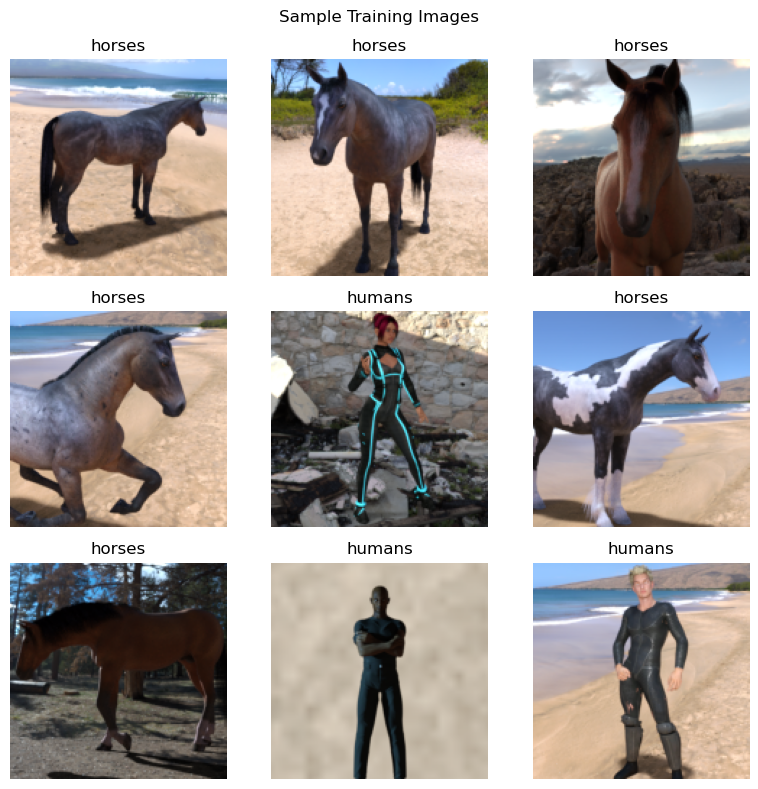

In [2]:
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()

## 3. Preprocessing and Data Augmentation

Pixel values are rescaled from `[0, 255]` to `[0, 1]` inside the model (a `Rescaling` layer), and training images are randomly flipped, rotated and zoomed on the fly so the CNN generalizes better instead of memorizing exact poses.

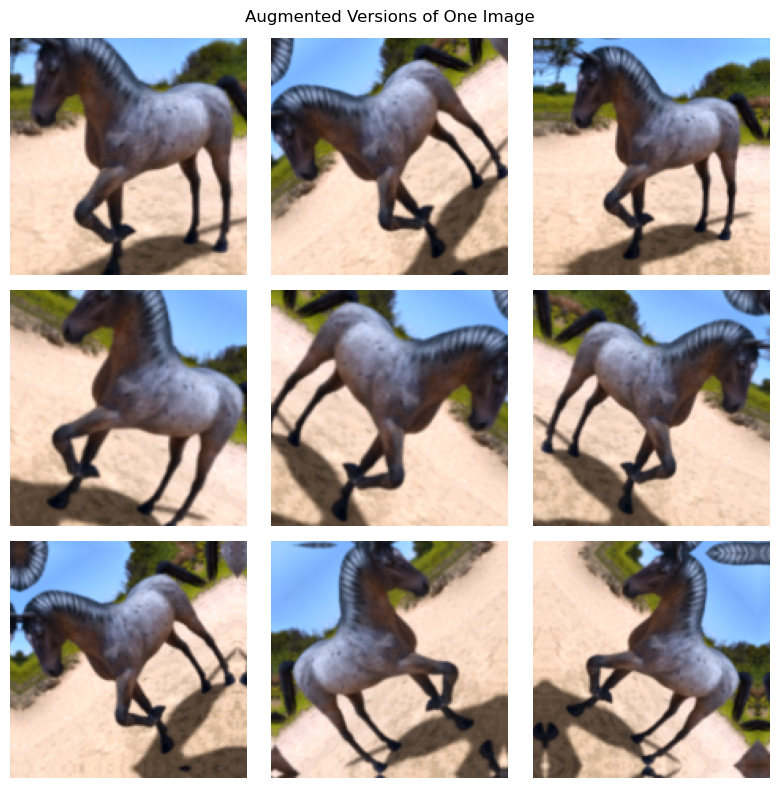

In [3]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="data_augmentation")

# Preview augmented versions of the same image
plt.figure(figsize=(8, 8))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented = data_augmentation(images[:1], training=True)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented[0].numpy().astype("uint8"))
        plt.axis("off")
plt.suptitle("Augmented Versions of One Image")
plt.tight_layout()
plt.show()

AUTOTUNE = tf.data.AUTOTUNE
train_ds_aug = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y)).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

## 4. Build the CNN Model

In [4]:
keras.utils.set_random_seed(42)  # reset so weight init is reproducible regardless of earlier cells

model = keras.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, activation="relu"),   # Conv block 1
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation="relu"),   # Conv block 2
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),   # Conv block 3
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),   # Conv block 4
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.5),                        # Regularization
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid"),       # Binary output
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,345 (1020.88 KB)

 Trainable params: 261,345 (1020.88 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile

In [5]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

## 6. Train the Model

Using `EarlyStopping` on validation accuracy (with `restore_best_weights=True`) so training stops once the model stops improving on unseen data, instead of overfitting further.

In [6]:
EPOCHS = 30

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=6, restore_best_weights=True
)

history = model.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=0,
    callbacks=[early_stop],
)

trained_epochs = len(history.history["loss"])
for epoch in range(trained_epochs):
    print(f"Epoch [{epoch+1:2d}/{trained_epochs}] | Train Loss: {history.history['loss'][epoch]:.4f} | "
          f"Train Acc: {history.history['accuracy'][epoch]*100:.1f}% | "
          f"Val Loss: {history.history['val_loss'][epoch]:.4f} | "
          f"Val Acc: {history.history['val_accuracy'][epoch]*100:.1f}%")

/opt/anaconda3/envs/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch [ 1/9] | Train Loss: 0.6890 | Train Acc: 53.6% | Val Loss: 0.6777 | Val Acc: 50.0%
Epoch [ 2/9] | Train Loss: 0.6715 | Train Acc: 67.4% | Val Loss: 0.6360 | Val Acc: 52.7%
Epoch [ 3/9] | Train Loss: 0.6150 | Train Acc: 73.8% | Val Loss: 0.4643 | Val Acc: 78.5%
Epoch [ 4/9] | Train Loss: 0.4683 | Train Acc: 82.8% | Val Loss: 0.9587 | Val Acc: 60.2%
Epoch [ 5/9] | Train Loss: 0.3827 | Train Acc: 84.2% | Val Loss: 0.8046 | Val Acc: 73.8%
Epoch [ 6/9] | Train Loss: 0.3310 | Train Acc: 86.5% | Val Loss: 1.1253 | Val Acc: 70.3%
Epoch [ 7/9] | Train Loss: 0.2986 | Train Acc: 88.1% | Val Loss: 1.0585 | Val Acc: 72.7%
Epoch [ 8/9] | Train Loss: 0.2625 | Train Acc: 89.1% | Val Loss: 1.3627 | Val Acc: 69.9%
Epoch [ 9/9] | Train Loss: 0.2811 | Train Acc: 87.8% | Val Loss: 1.1762 | Val Acc: 71.1%


## 7. Training Curves

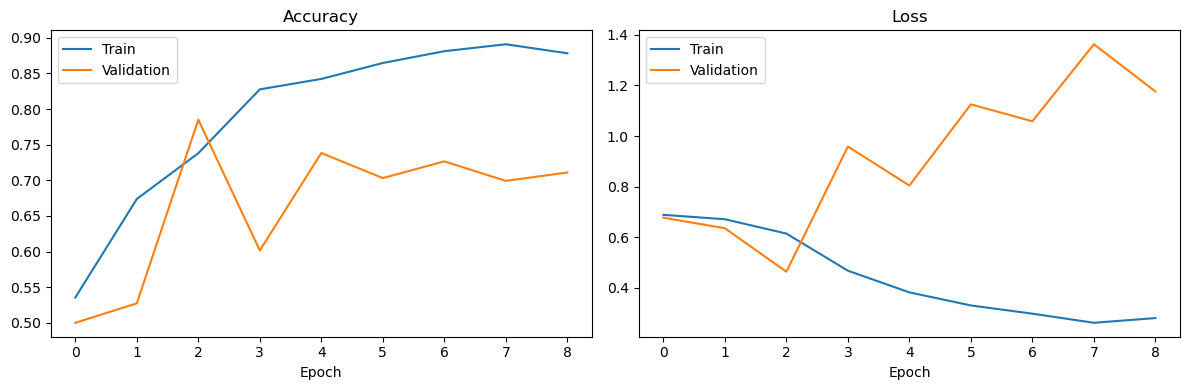

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Final Evaluation and Interpretation

In [8]:
print("\n-- Final Results --")
val_loss, val_accuracy = model.evaluate(val_ds, verbose=0)
n_val = sum(1 for _ in val_ds.unbatch())
correct = int(round(val_accuracy * n_val))
print(f"Validation Accuracy: {val_accuracy*100:.1f}%  ({correct}/{n_val} correct)")

# Confusion matrix
y_true = np.concatenate([y.numpy() for _, y in val_ds]).ravel()
y_prob = model.predict(val_ds, verbose=0).ravel()
y_pred = (y_prob > 0.5).astype(int)

cm = np.zeros((2, 2), dtype=int)
for t, p in zip(y_true.astype(int), y_pred):
    cm[t, p] += 1

print("\nConfusion Matrix (rows = actual, cols = predicted)")
print(f"                 pred:{class_names[0]:>8s}  pred:{class_names[1]:>8s}")
for i, name in enumerate(class_names):
    print(f"actual:{name:>8s}  {cm[i,0]:>14d}  {cm[i,1]:>14d}")

precision = cm[1,1] / (cm[0,1] + cm[1,1] + 1e-9)
recall = cm[1,1] / (cm[1,0] + cm[1,1] + 1e-9)
print(f"\nPrecision ({class_names[1]}): {precision*100:.1f}%  |  Recall ({class_names[1]}): {recall*100:.1f}%")


-- Final Results --


Validation Accuracy: 78.5%  (201/256 correct)



Confusion Matrix (rows = actual, cols = predicted)
                 pred:  horses  pred:  humans
actual:  horses              40              88
actual:  humans              33              95

Precision (humans): 51.9%  |  Recall (humans): 74.2%


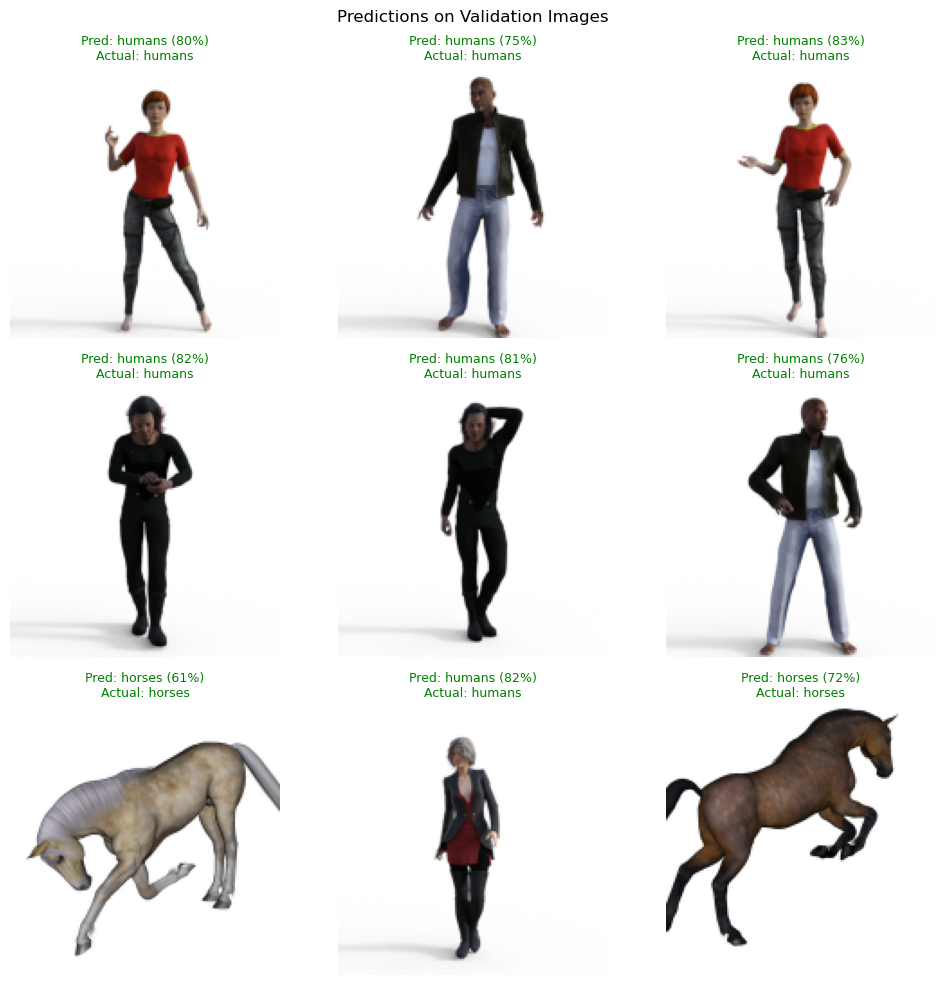

In [9]:
# Visualize some predictions
plt.figure(figsize=(10, 10))
for images, labels in val_ds.take(1):
    preds = model.predict(images, verbose=0).ravel()
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        actual = class_names[int(labels[i].numpy().item())]
        predicted = class_names[int(preds[i] > 0.5)]
        confidence = preds[i] if preds[i] > 0.5 else 1 - preds[i]
        color = "green" if predicted == actual else "red"
        plt.title(f"Pred: {predicted} ({confidence*100:.0f}%)\nActual: {actual}", color=color, fontsize=9)
        plt.axis("off")
plt.suptitle("Predictions on Validation Images")
plt.tight_layout()
plt.show()

## 9. Observations

- The CNN learns hierarchical visual features automatically (edges -> textures -> shapes) through the stacked `Conv2D` + `MaxPooling2D` blocks, without any hand-crafted feature engineering.
- Data augmentation (`RandomFlip`, `RandomRotation`, `RandomZoom`) reduces the gap between training and validation accuracy by exposing the model to more pose/orientation variety from the same 1027 training images.
- `Dropout(0.5)` before the dense layers curbs overfitting on this relatively small dataset.
- Misclassified images (shown in red above) are usually ones with unusual poses, cropping, or backgrounds that differ from the bulk of the training distribution — expected behavior for a small CNN trained from scratch rather than a pretrained backbone.